<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/Pr%C3%A1ctica_Sentiment_Analysis_S12(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Análisis de Sentimiento de IMD Movie Reviews**


**Dataset**: imdb_10K_sentimnets_reviews.csv

# **Contexto del Problema**

Las reseñas de películas ayudan a los usuarios a decidir si una película merece la pena verla o no. Un resumen de las reseñas de una película puede ayudar a un usuario a tomar decisiones rápidas en un corto período de tiempo, en lugar de pasar mucho más tiempo leyendo múltiples reseñas de una película. El análisis de sentimiento ayuda a calificar cuán positiva o negativa es una reseña de película. Por lo tanto, el proceso de comprender si una reseña es positiva o negativa puede automatizarse a medida que la máquina aprende diferentes técnicas del campo del Procesamiento del Lenguaje Natural.

## **Objetivo**

El conjunto de datos contiene 10,000 reseñas de películas. El objetivo es realizar un Análisis de Sentimientos (positivo/negativo) para las reseñas de películas utilizando diferentes técnicas, como métodos de aprendizaje supervisado y no supervisado, y comparar cuál de ellos proporciona los resultados mejores y más precisos.

POdemos abordar este objetivo usando:
**Modelos supervisados** - Algunas técnicas populares utilizadas para codificar texto:

* Bolsa de Palabras (Bag of Words)
* TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento)

**Modelos no supervisados** - Algunas técnicas populares utilizadas para el Análisis de Sentimiento no supervisado:

* TextBlob
* Sentimiento VADER
   


## **Diccionario de datos**
* **review:** reseñas de las películas.
sentimiento: indica el sentimiento de la reseña, 0 o 1 (0 es para * **reseñas** negativas y 1 para reseñas positivas).

# **Fuente del conjunto de datos:**
IMDB Movie Ratings Sentiment Analysis: https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis

# **Resumen del conjunto de datos:**

## **Importando las librerías**

In [ ]:
# Importando las librerías

# Para leer y manipular los datos
import pandas as pd
pd.set_option('max_colwidth', None)

# Para las gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Apoya en mostrar las imágenes
from PIL import Image

# Ayuda a extraer los datos utilizando expresiones regulares.
import re

# Apoya en remover la puntuación
import string

#Instala Unidecode
! pip install Unidecode


# Apoya en remover los acentos
import unidecode

# Importa la librería NLTK (Natural Language Toolkit)
import nltk

nltk.download('stopwords')    # Carga las stopwords
nltk.download('punkt')        # Para la tokenización
nltk.download('omw-1.4')      # Carga una dependencia necesaria para la tokenización
nltk.download('wordnet')      # Cargando el módulo WordNet, utilizado en el stemming y la lematización.

# Baja el léxico de VADED
nltk.download('vader_lexicon')

from nltk.corpus import stopwords

# Apoyo en la creación de Word clouds
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Usaddo en la lematización
from nltk.stem.porter import PorterStemmer


# Usaddo en la lematización
from nltk.stem import WordNetLemmatizer


from sklearn.feature_extraction.text import CountVectorizer          #Para BofW
from sklearn.feature_extraction.text import TfidfVectorizer          #ParaTF-IDF

# Creación de train y test
from sklearn.model_selection import train_test_split

# Para crear el modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier

# Para generar las métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# MODELOS NO SUPERVISADOS

# Instalando VADER
!pip install vaderSentiment

# Instalando TextBlob
!pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 7.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00


## **Cargando la base de datos**

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from google.colab import files
# Debes subir: imdb_10K_sentimnets_reviews.csv
uploaded = files.upload()

Saving imdb_10K_sentimnets_reviews.csv to imdb_10K_sentimnets_reviews.csv


In [ ]:
# Creando un dataframe para la base obtenida
reviews = pd.read_csv("imdb_10K_sentimnets_reviews.csv")

In [ ]:
# Creando una copia
data = reviews.copy()

## **Entendiendo la base de datos**

In [ ]:

data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

In [ ]:
data.tail()

,review,sentiment
9995,"A masterpiece.<br /><br />Thus it is, possibly, not for everyone.<br /><br />The camera work, acting, directing and everything else is unique, original, superb in every way - and very different from the trash we are sadly used to getting.<br /><br />Summer Phoenix creates a deep, believable and intriguing Esther Kahn. As everything else in this film, her acting is unique - it is completely her own - neither ""British"" nor ""American"" nor anything else I have ever seen. There is something mesmerizing about it.<br /><br />The lengthy, unbroken, natural shots are wonderful, reminding us that we have become too accustomed to a few restricted ways of shooting and editing.",1
9996,"Great movie about a great man. Thomas Kretschmann is first rate as in all of his other movies.I would never have envisioned him as Pope John Paul. It speaks volumes for the casting director. Why do they keep casting him as German officer in the movies? And he only came to universal attention after ""the pianist""? Of course he looks so hot in the uniforms. I know a lot of girls drool over his handsome face. But this guy is a great actor and has such great potentials. If you don't believe me, go watch ""Stalingrad"". I hope he will get a lot of excellent roles in the future with more diversity. Otherwise, what a heartbreaking waste of great talent.",1
9997,"Before we start, may I say I hope you've already eaten when you're reading this. Why? Because, after I'd seen this film for the first time, the bird's look and sound made me want to eat chicken after the words 'The End' had appeared on the screen. So don't say you weren't warned.<br /><br />Fred Sears might have directed ""Earth vs. the Flying Saucers"" (an okay film and one of the bigger examples for Tim Burton's ""Mars Attacks""), but ""The Giant Claw"" is not that giant a film. Yes, it's a prehistoric monster that flies in the air, attacks planes and cities and occasionally treats itself to a man on a parachute. The beast is giant except in the scenes where it's considerably smaller, but who needs consistent proportions in a movie? Scary? It could have been, but not if the plot is hopelessly silly and the monster looks like like a puppet that ran away from Sesame Street.",0
9998,"I was so disappointed by this show. After hearing and reading all the hoopla about it, how it was a ""ground breaking show"" and all sorts of wild promises if quality, I tried to watch it.<br /><br />What a letdown!! The acting was way forced and exaggerated. The story made very little sense. As for any hint of the vaunted ""look into teenagers' lives"", I could only see a paltry attempt that had as much reality to it as a reality show.<br /><br />Some are wondering why there are so many negative comments about this show. The reason is that it's really not all that good and beating the drums over quality on this show only serves to attract attention to how poorly made it is.",0
9999,"The 3-D featured in ""The Man Who Wasn't There"" stands for DUMB, DUMB, DUMB! This inept comedy features lousy 3-D effects that makes the 3-D effects in ""Jaws 3"", ""Amityville 3"", and ""Friday the 13th Part 3"" look better by comparison. Not to mention the movie is asinine to the extreme. This was one of many 1983 movies to feature the pop-off-the-screen effects. Steve Guttenberg and Jeffrey Tambor got trapped in this mess, but at least it didn't kill their careers. Tambor would go on to star on HBO's ""The Larry Sanders Show"" and Ron Howard's box office smash ""How the Grinch Stole Christmas"", while Guttenberg followed this flop with ""Police Academy"" and ""Cocoon"". What them in those projects instead of them here in ""The Man Who Wasn't There"". If you do, you'll regret it.<br /><br />1/2* (out of four)",0



Aquí, un valor de sentimiento de 0 representa negativo y 1 representa un sentimiento positivo.

In [ ]:
# Viendo el "shape" de la base
data.shape

(10000, 2)

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


* Hay una variable objeto y una numérica
* No hay valores nulos en la base

In [ ]:
# Revisando valores duplicados
data.duplicated().sum()

np.int64(18)

In [ ]:
# Eliminando lus diplicados
data = data.drop_duplicates(keep = 'first')

data.duplicated().sum()

np.int64(0)

In [ ]:
# Re-generando los indices para la base
data = data.reset_index(drop = True)

* Los valores duplicados han sido removidos.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     9982 non-null   object
 1   sentiment  9982 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 156.1+ KB


# **Análisis de datos exploratorio**

In [ ]:
# Creando una wordcloud para los valores negativos

negative_reviews = data[data['sentiment'] == 0]

words = ' '.join(negative_reviews['review'])

cleaned_word = " ".join([word for word in words.split()])

In [ ]:
wordcloud = WordCloud(stopwords = STOPWORDS,
                      background_color = 'white',
                      width = 3000,
                      height = 2500
                     ).generate(cleaned_word)

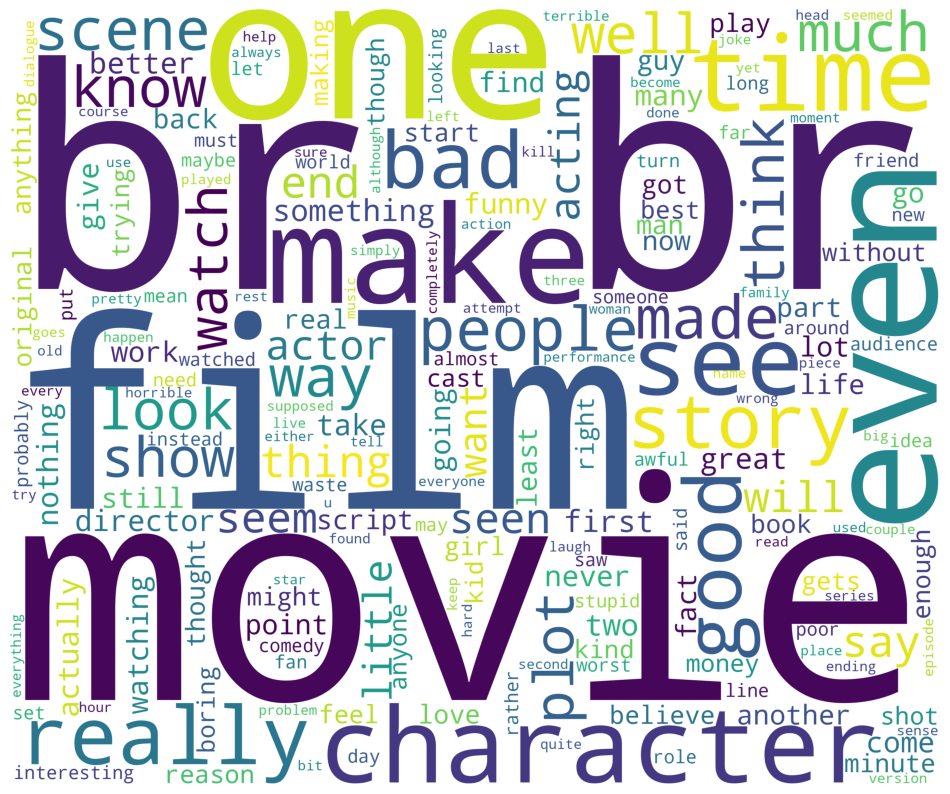

In [ ]:
plt.figure(1, figsize = (12, 12))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

* The **made, film, makebad, worst, least, maybe, instead, waste, terrible, still, boring** fueron algunas palabras que se repitieron en las frases negativas.

In [ ]:
# Creando el word cloud para los sentimientos positivos
positive_reviews = data[data['sentiment'] == 1]

words = ' '.join(positive_reviews['review'])

cleaned_word = " ".join([word for word in words.split()])

In [ ]:
wordcloud = WordCloud(stopwords = STOPWORDS,
                      background_color = 'white',
                      width = 3000,
                      height = 2500
                     ).generate(cleaned_word)

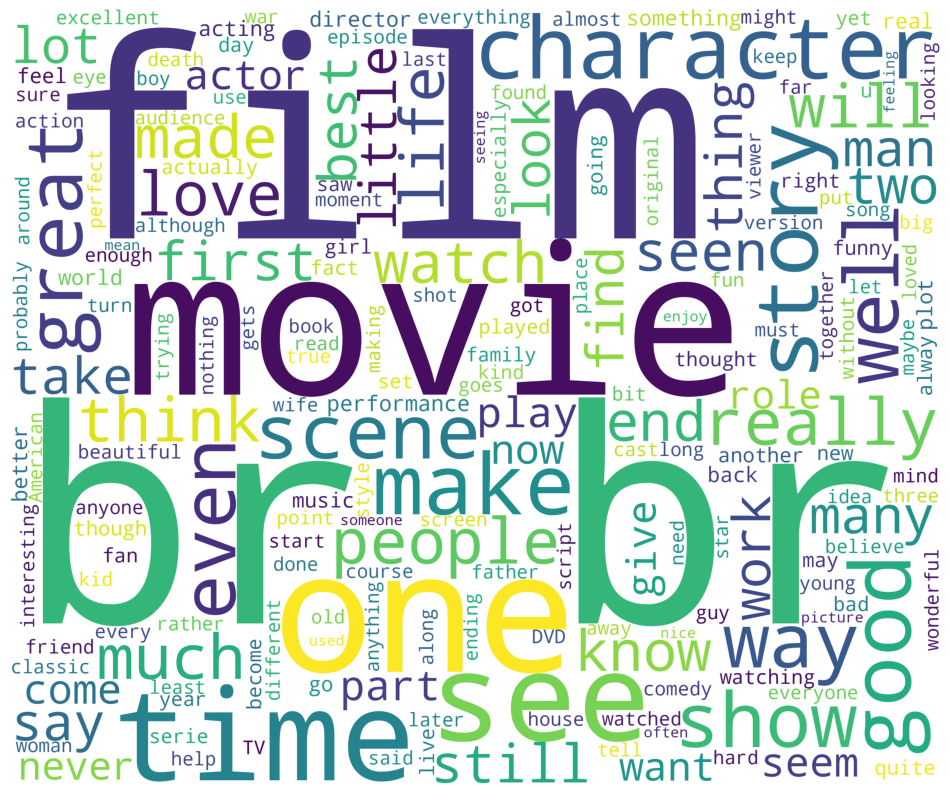

In [ ]:
plt.figure(1, figsize = (12, 12))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

* **well, good, best, great, enjoy, interesting, wonderful, much, fun, beautiful, fun** fueron algunas de las palabras importantes observadas en las reseñas positivas.






In [ ]:
# Revisando las etiquetas
data['sentiment'].unique()

array([1, 0])

In [ ]:
# Viendo el % de las etiquetas
data['sentiment'].value_counts(True)

,proportion
sentiment,
1,0.504208
0,0.495792


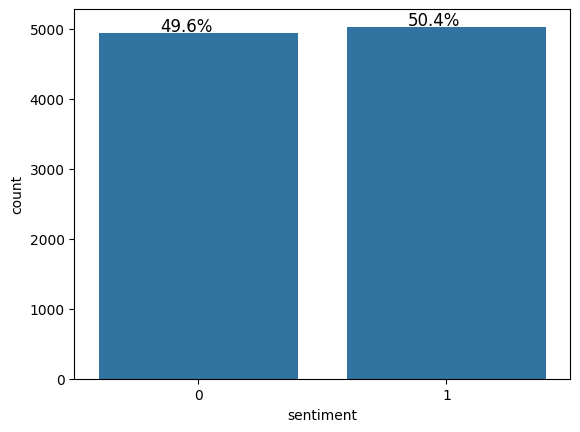

In [ ]:
# Graficar la distribución de la etiqueta de clase.
def bar_plot(data, feature):
    # creando el countplot
    plot = sns.countplot(x = feature, data = data)

    # Obteniendo el tamaño de la base
    total = len(data)

    # Creando los %  para cada etiqueta
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y),ha="center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points")
    plt.show()

bar_plot(data,'sentiment')

Las etiquetas de los datos estaban bastante equilibradas, así que podemos continuar y proceder con el proceso adicional.

# **Pre-procesamiento de los datos**

Antes de proceder a construir el modelo, debemos limpiar los datos para obtener un mejor rendimiento del modelo.

In [ ]:
# Creando el lematizador

lm = WordNetLemmatizer()

In [ ]:
final_corpus = []     # OJO tardar alrededor de 4 min

for i in range(data.shape[0]):

    # Eliminar los caracteres especiales y los números de los datos.
    review = re.sub('[^a-zA-Z]', ' ', data['review'][i])

    # Convertir el texto a minúsculas.
    review = review.lower()

    review = review.split()

    # Eliminar las palabras acentuadas.
    review = [unidecode.unidecode(word) for word in review]

    # Eliminar las palabras vacías (stopwords) y crear palabras de léxico (lemmas) para cada palabra presente en cada fila.
    review = [lm.lemmatize(word) for word in review if not word in stopwords.words('english')]

    # Uniendo el corpus.
    review = ' '.join(review)

    # Añadiendo el resultado a una nueva lista llamada "final_corpus".

    final_corpus.append(review)

In [ ]:
# Echemos un vistazo al texto limpio.
final_corpus[0]

'okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done'

In [ ]:
final_corpus[1]

'despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth ren

In [ ]:
# Guardando el texto limpio nuevamente en la columna de reseñas.
data['review'] = final_corpus

In [ ]:
data.head(5)

,review,sentiment
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1



Hemos limpiado con éxito el texto sin procesar y lo hemos guardado nuevamente en la columna de reseñas. Ahora, construyamos los modelos.

# **Aprendizaje supervisado para Sentiment Analysis**

## **Bag of Words (CountVectorizer)**
      
En BoW (Bolsa de Palabras), construimos un diccionario que contiene el conjunto de todas las palabras únicas de nuestro conjunto de datos de reseñas de texto. Aquí se cuenta la frecuencia de las palabras. Si hay d palabras únicas en nuestro diccionario, entonces para cada reseña, el vector tendrá una longitud de d, y la cantidad de veces que aparece cada palabra en las reseñas se almacena en su ubicación particular en el vector. El vector será altamente disperso (sparse) en tales casos, ya que la mayoría de las ubicaciones tendrán un valor de cero debido a las palabras que no aparecen en una reseña específica.


In [ ]:
# Para ejecutar la vectorización
from sklearn.feature_extraction.text import CountVectorizer

# Mantener solo 1000 características, ya que el número de características aumentará el tiempo de procesamiento.
Count_vec = CountVectorizer(max_features = 1000)

data_features = Count_vec.fit_transform(data['review'])

# Convertir las características de los datos a un arreglo (array).
data_features = data_features.toarray()

In [ ]:
# Shape del feature vector
data_features.shape

(9982, 1000)

In [ ]:
X = data_features

y = data.sentiment

In [ ]:
# Función para imprimir el informe de clasificación y obtener la matriz de confusión en un formato adecuado.

def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['negative', 'positive'], yticklabels = ['negative', 'positive'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

In [ ]:
# Dividir los datos en un conjunto en trainig  y test.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1218
           1       0.84      0.80      0.82      1278

    accuracy                           0.82      2496
   macro avg       0.82      0.82      0.82      2496
weighted avg       0.82      0.82      0.82      2496



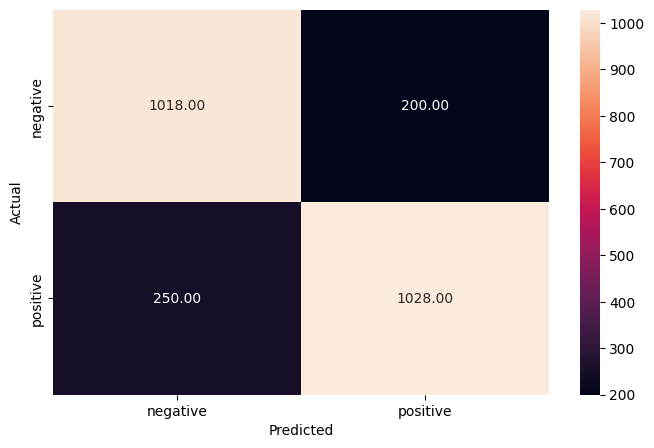

In [ ]:
# Entrenar el mejor modelo y calcular la precisión en los datos de prueba.

clf = RandomForestClassifier(n_estimators = 100)

clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)

metrics_score(y_test, y_pred_test)

In [ ]:
def get_top40_words(model, all_features):

    # Añadir las 40 características principales a la lista top_feature después de entrenar el modelo.
    top_features=''

    feat = model.feature_importances_

    features = np.argsort(feat)[::-1]

    for i in features[0:40]:
        top_features+=all_features[i]
        top_features+=','

    from wordcloud import WordCloud

    wordcloud = WordCloud(background_color = "white", colormap = 'viridis', width = 2000,
                              height = 1000).generate(top_features)

    # Display the generated image:
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.figure(1, figsize = (14, 11), frameon='equal')
    plt.title('Nube de palabras del Top 40 características', fontsize = 10)
    plt.axis("off")
    plt.show()

/tmp/ipykernel_10631/3220925964.py:21: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize = (14, 11), frameon='equal')


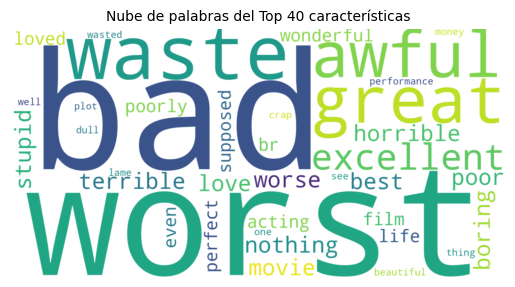

In [ ]:
import numpy as np

 # Traer las características desde el vectorizador

features = Count_vec.get_feature_names_out()

get_top40_words(clf,features)

## **5.2 TF-IDF**


Frecuencia de Término - Frecuencia Inversa de Documento: Se asegura de que se dé menos importancia a las palabras más frecuentes y también considera las palabras menos frecuentes.

In [ ]:
# Utilizando TfidfVectorizer para convertir datos de texto en números.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(max_features = 1000)

data_features = tfidf_vect.fit_transform(data['review'])

data_features = data_features.toarray()

# Feature shape
data_features.shape

(9982, 1000)

In [ ]:
X = data_features

y = data.sentiment

In [ ]:
# Dividir los datos en un conjunto de entrenamiento y un conjunto de prueba.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81      1218
           1       0.83      0.80      0.82      1278

    accuracy                           0.81      2496
   macro avg       0.82      0.82      0.81      2496
weighted avg       0.82      0.81      0.81      2496



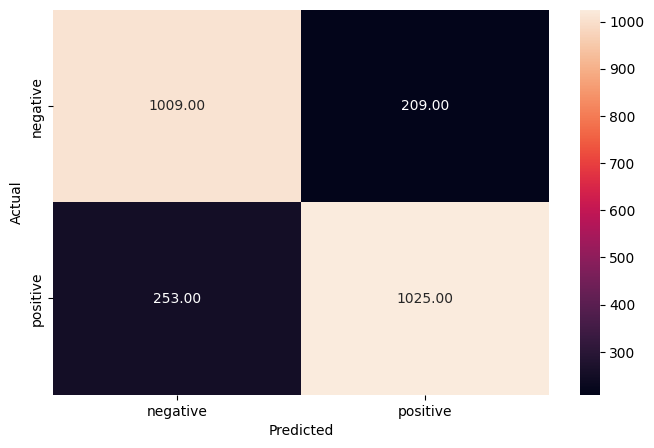

In [ ]:
# Entrenando el mejor modelo y calculando la precisión en los datos de prueba.

clf1 = RandomForestClassifier(n_estimators = 100)

clf1.fit(X_train, y_train)

y_pred_test1 = clf1.predict(X_test)

metrics_score(y_test, y_pred_test1)

/tmp/ipykernel_10631/3220925964.py:21: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize = (14, 11), frameon='equal')


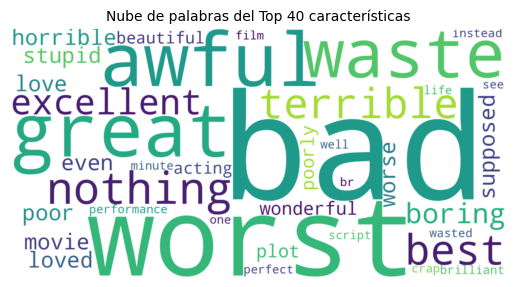

In [ ]:
# Iniciar la característica del vectorizador
features = tfidf_vect.get_feature_names_out()

get_top40_words(clf1,features)

In [ ]:
#Comparando las puntuaciones de los métodos de aprendizaje supervisado: Contador de Vectores (Count Vectorizer) y TF-IDF.


#Las etiquetas y_test (etiquetas verdaderas), etiquetas predichas por el modelo TF-IDF (tf_idf_predicted),
#etiquetas predichas por el modelo Count Vectorizer (count_vectorizer_predicted)

df = pd.DataFrame(y_test.tolist(), columns = ['y_test'])

df['count_vectorizer_predicted'] = y_pred_test

df['tf_idf_predicted'] = y_pred_test1

df.head()

,y_test,count_vectorizer_predicted,tf_idf_predicted
0,1,1,1
1,1,1,1
2,1,1,1
3,0,1,0
4,1,1,1



Count Vectorizer muestra un mejor rendimiento.

## **Aprendizaje No Supervisado para el Análisis de Sentimientos**

## **VADER**
VADER (Valence Aware Dictionary and Sentiment Reasoner) es una biblioteca o herramienta de análisis de sentimientos basada en léxicos y reglas. No solo proporciona la puntuación de positividad y negatividad de un sentimiento, sino que también nos dice el grado de positividad o negatividad del mismo.

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sentiment = SentimentIntensityAnalyzer()

In [ ]:
data_new = data.copy()   # Realiza una copia de los datos (dataframe)

In [ ]:
# Calcula la puntuación de polaridad de las reseñas.
data_new['scores'] = data_new['review'].apply(lambda text: sentiment.polarity_scores(text))

data_new.head()

,review,sentiment,scores
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,"{'neg': 0.17, 'neu': 0.549, 'pos': 0.281, 'compound': 0.836}"
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,"{'neg': 0.109, 'neu': 0.632, 'pos': 0.259, 'compound': 0.9836}"
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,"{'neg': 0.26, 'neu': 0.43, 'pos': 0.309, 'compound': 0.5946}"
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,"{'neg': 0.153, 'neu': 0.696, 'pos': 0.15, 'compound': -0.0772}"
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1,"{'neg': 0.118, 'neu': 0.676, 'pos'

In [ ]:
# Extrae la puntuación compuesta (compound score) de las reseñas.
data_new['compound']  = data_new['scores'].apply(lambda score_dict: score_dict['compound'])

data_new.head()

,review,sentiment,scores,compound
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,"{'neg': 0.17, 'neu': 0.549, 'pos': 0.281, 'compound': 0.836}",0.8360
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,"{'neg': 0.109, 'neu': 0.632, 'pos': 0.259, 'compound': 0.9836}",0.9836
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,"{'neg': 0.26, 'neu': 0.43, 'pos': 0.309, 'compound': 0.5946}",0.5946
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,"{'neg': 0.153, 'neu': 0.696, 'pos': 0.15, 'compound': -0.0772}",-0.0772
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film

In [ ]:
# Clasifica la clase de la reseña estableciendo un umbral en la puntuación compuesta (compound score).

data_new['comp_score'] = data_new['compound'].apply(lambda c: '1' if c >=0 else '0')

data_new.head()

,review,sentiment,scores,compound,comp_score
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,"{'neg': 0.17, 'neu': 0.549, 'pos': 0.281, 'compound': 0.836}",0.8360,1
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,"{'neg': 0.109, 'neu': 0.632, 'pos': 0.259, 'compound': 0.9836}",0.9836,1
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,"{'neg': 0.26, 'neu': 0.43, 'pos': 0.309, 'compound': 0.5946}",0.5946,1
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,"{'neg': 0.153, 'neu': 0.696, 'pos': 0.15, 'compound': -0.0772}",-0.0772,0
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style a

In [ ]:
#Asignamos la puntuación de VADER a la base original
data["VADER_pred"] = data_new['comp_score'].tolist()
data.head()

,review,sentiment,VADER_pred
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,1
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,1
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,1
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,0
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1,1


              precision    recall  f1-score   support

           0       0.78      0.47      0.59      4949
           1       0.63      0.87      0.73      5033

    accuracy                           0.67      9982
   macro avg       0.70      0.67      0.66      9982
weighted avg       0.70      0.67      0.66      9982



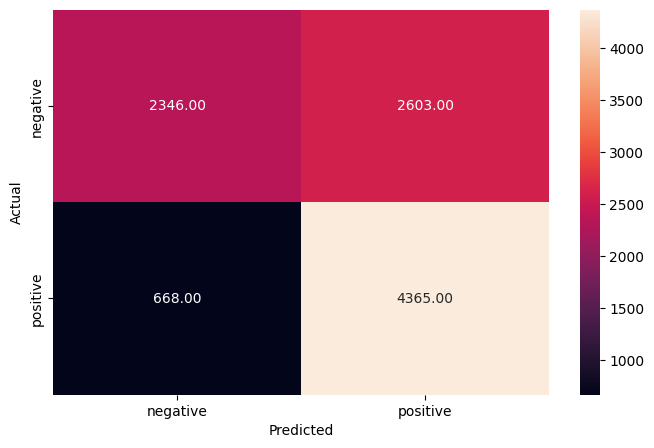

In [ ]:
# Calcula la precisión del Análisis de Sentimiento de Vader.
data["sentiment"] = data["sentiment"].astype(int)   #Convierte los valores de la columna de sentimiento en tipo de dato entero (int).

data["VADER_pred"] = data["VADER_pred"].astype(int) #Convierte los valores de la columna de sentimiento en tipo de dato entero (int).

metrics_score(data["sentiment"], data["VADER_pred"])

## **TextBlob**

TextBlob es una biblioteca en el campo del Procesamiento del Lenguaje Natural (NLP) que simplifica tareas de procesamiento de texto en Python. En resumen:

* **Análisis de Sentimiento**: TextBlob puede realizar un análisis de sentimiento en el texto, determinando si es positivo, negativo o neutro, lo que es útil para comprender la opinión o actitud expresada en el texto.

* **Procesamiento de Texto**: Permite realizar tareas de procesamiento de texto como tokenización (dividir el texto en palabras), lematización (encontrar la forma base de las palabras), y extracción de frases clave de manera sencilla.

* **Traducción de Texto:** Puede traducir texto entre diferentes idiomas, lo que es útil para aplicaciones de internacionalización o para comprender contenido en idiomas diferentes.

* **Clasificación de Texto:** A través de su capacidad de análisis de sentimiento, TextBlob también se utiliza para tareas de clasificación de texto, como la categorización de documentos o la detección de spam.

En general, TextBlob simplifica muchas tareas comunes de procesamiento de texto en NLP y proporciona una interfaz fácil de usar para trabajar con texto en Python.

In [ ]:
from textblob import TextBlob

In [ ]:
data_new = data.copy()      # Hacer una copia del DataFrame y realizar operaciones no supervisadas en ese DataFrame.

In [ ]:
# Calcular la puntuación de polaridad de las reseñas.
data_new['polarity']  = data_new['review'].apply(lambda text: TextBlob(text).sentiment.polarity)

data_new.head()

,review,sentiment,VADER_pred,polarity
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,1,0.230303
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,1,0.158824
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,1,0.176914
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,0,-0.151240
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1,1,0.111097


In [ ]:
# Clasificar la clase de la reseña estableciendo un umbral en la puntuación de polaridad.
data_new['polarity_score'] = data_new['polarity'].apply(lambda c: '1' if c >=0 else '0')

data_new.head()

,review,sentiment,VADER_pred,polarity,polarity_score
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,1,0.230303,1
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,1,0.158824,1
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,1,0.176914,1
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,0,-0.151240,0
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1,1,0.111097,1


In [ ]:
data["Text_Blob_pred"] = data_new['polarity_score'].tolist()
data.head()

,review,sentiment,VADER_pred,Text_Blob_pred
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribly wrong interaction nandini father law power dysfunctional relationship life changed strength movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption life film find heaving sigh relief sadness climax musical interlude strength believable well done,1,1,1
1,despite john travolta statement interview favorite role career cool prof disappointing sequel witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie fall flat due underdeveloped plot unlikeable character surprising lack chemistry lead travolta uma thurman although laugh unfunny dialog example appeared frequently trailer kind say thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movie clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character think black often seen dressed pimp quite funny first scene introduces get tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fan get shorty may actually wish avoid sequel devoid thing made one winner rate movie admittedly harsh,0,1,1
2,kung fu fan woo fan interest gangster movie filled top gun play martial art beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scene good less good main character amusing likable bad guy bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewing however last hurrah chivalry tend get little boring long winded also especially many fight scene actually good hence rate really almost br br one better kung fu movie made smack dab heart kung fu cinema prime really good kung fu movie mid late y notable exception late y early y early y fair,1,1,1
3,seems control freak heard comment losing control show tell another guest brought live animal one rule snake need hire comedy writer joke lame reason watch great guest band br br watched craig ferguson show show even worse like bull sh burn time think either man much future late night talk show br br daily also annoying habit sticking tongue lick lip must least time show like joe firstman band carson daily need lighten late,0,0,0
4,admittedly scene movie seem little unrealistic ravishing woman first panic minute later start kissing young lad old guy right next film go along learn little volatile girl slut partly explains behavior cinematography movie well done get see elevator almost every angle perspective image scene really raise tension g tz george play character well wannabe hot shot getting old overpowered young men like jaennicke character wolfgang kieling admired hitchcock torn curtain delivers great performance although say much far best actor play one critic complained unrealistic film real case emergency nothing would really happen realistic film mission impossible phone booth given fact talking movie movie always deal scene likely occur real life still enjoy movie lot better many thing see german tv day think vintage style added something film,1,1,1


              precision    recall  f1-score   support

           0       0.88      0.46      0.61      4949
           1       0.64      0.94      0.76      5033

    accuracy                           0.70      9982
   macro avg       0.76      0.70      0.68      9982
weighted avg       0.76      0.70      0.68      9982



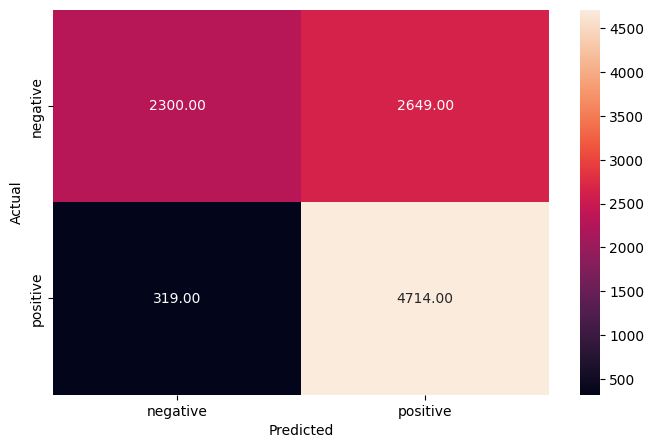

In [ ]:
# Calcular la precisión del Análisis de Sentimiento para TEXT BLOB.
data["sentiment"] = data["sentiment"].astype(int)  #Convertir los valores de la columna de sentimiento en tipo de dato entero (int).

data["Text_Blob_pred"] = data["Text_Blob_pred"].astype(int)  #Convertir los valores de la columna de sentimiento en tipo de dato entero (int).

metrics_score(data["sentiment"], data["Text_Blob_pred"])

**Aquí, TextBlob funciona mejor que Vader porque éste (Vader) generalmente funciona mejor con frases o lenguaje especializado como jerga, emojis, etc., mientras que TextBlob se desempeña mejor con un uso más formal del lenguaje.**

# **Conclusión**

* Para el análisis de sentimientos, utilizamos dos enfoques de aprendizaje supervisado, TF-IDF y Bag-of-Words, y dos técnicas de aprendizaje no supervisado, TextBlob y Vader.

* En las técnicas de aprendizaje supervisado, TF-IDF supera a BoW ya que no solo considera la frecuencia de las palabras en el corpus, sino también su importancia.

* Textblob tuvo un mejor rendimiento que Vader entre los algoritmos de aprendizaje no supervisado, ya que nuestro conjunto de datos comprende reseñas de películas que tienden a utilizar un lenguaje más formal.

### **FIN DEL NOTEBOOK**